# Data cleaning

Like EDA, except loading preprocessed data to investigate effective methods for removing motion artifacts

In [1]:
# Imports

# Load preprocessed data

import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
from scipy.fft import rfft, rfftfreq


%matplotlib widget
plt.close('all')

In [2]:
# Load data

PREPROC_PATH = "/Volumes/LPM02 storage/Datasets/Bio/DaLiA/data/data_preproc_fs16.pkl"

with open(PREPROC_PATH, 'rb') as f:
    preproc = pkl.load(f)

data_preproc = preproc['data']
params       = preproc['params']

# Unpack params as module-level constants
FS        = params['FS']
BPF_FC1   = params['BPF_FC1']
BPF_FC2   = params['BPF_FC2']
BPF_ORDER = params['BPF_ORDER']
T_WIN     = params['T_WIN']
T_STRIDE  = params['T_STRIDE']
N_WIN     = params['N_WIN']
N_STRIDE  = params['N_STRIDE']

print("Loaded preprocessed data")
print(f"  Subjects : {list(data_preproc.keys())}")
print(f"  FS       : {FS} Hz")
print(f"  BPF      : {BPF_FC1}–{BPF_FC2} Hz, order {BPF_ORDER}")
print(f"  Window   : {T_WIN}s, stride {T_STRIDE}s ({N_WIN} samples, {N_STRIDE} stride)")
for subj_id, d in data_preproc.items():
    print(f"  {subj_id} — ppg: {d['ppg'].shape}, acc: {d['acc'].shape}, labels: {d['label'].shape}")

Loaded preprocessed data
  Subjects : ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15']
  FS       : 16 Hz
  BPF      : 0.4–4.0 Hz, order 4
  Window   : 8.0s, stride 2.0s (128 samples, 32 stride)
  S1 — ppg: (4603, 128, 1), acc: (4603, 128, 3), labels: (4603,)
  S2 — ppg: (4099, 128, 1), acc: (4099, 128, 3), labels: (4099,)
  S3 — ppg: (4367, 128, 1), acc: (4367, 128, 3), labels: (4367,)
  S4 — ppg: (4572, 128, 1), acc: (4572, 128, 3), labels: (4572,)
  S5 — ppg: (4649, 128, 1), acc: (4649, 128, 3), labels: (4649,)
  S6 — ppg: (2622, 128, 1), acc: (2622, 128, 3), labels: (2622,)
  S7 — ppg: (4668, 128, 1), acc: (4668, 128, 3), labels: (4668,)
  S8 — ppg: (4037, 128, 1), acc: (4037, 128, 3), labels: (4037,)
  S9 — ppg: (4277, 128, 1), acc: (4277, 128, 3), labels: (4277,)
  S10 — ppg: (5321, 128, 1), acc: (5321, 128, 3), labels: (5321,)
  S11 — ppg: (4521, 128, 1), acc: (4521, 128, 3), labels: (4521,)
  S12 — ppg: (3954, 128, 1), acc: (3954,

## NLMS Adaptive Filtering

- NLMS is used in the relevant literature with acc reference channel to clean noisy ppg

In [3]:
def nlms_filter(ppg, acc, mu, filter_len, eps=1e-8):
    """
    NLMS adaptive filter for motion artifact removal from PPG using ACC as reference.

    For each ACC channel, an NLMS adaptive filter estimates the motion artifact
    component v(n) in the observed PPG d(n) = s(n) + v(n). The error signal
    e(n) = d(n) - y(n) converges to the clean cardiac signal s(n) as the
    filter output y(n) converges to v(n).

    Inputs:
        ppg:        (N, 1)   normalized PPG window (desired signal d(n))
        acc:        (N, channels)   normalized ACC window (reference signal x(n))
        mu:         float    NLMS step size (0 < mu < 2)
        filter_len: int      number of adaptive filter taps
        eps:        float    stability constant to prevent division by zero

    Returns:
        ppg_clean:  (N, channels)   cleaned PPG signal, one per ACC channel
    """

    assert ppg.ndim == 2 and ppg.shape[1] == 1, "ppg must be shape (N, 1)"
    assert acc.ndim == 2, "acc must be shape (N, channels)"
    assert ppg.shape[0] == acc.shape[0], "ppg and acc must have equal length along dim 0"
    assert 0 < mu < 2, "mu must be in (0, 2) for NLMS stability"

    N = ppg.shape[0]
    channels = acc.shape[1]

    ppg_clean = np.zeros((N, channels))

    for c in range(channels):
        w = np.zeros(filter_len)

        for i in range(filter_len, N):
            x = np.flip(acc[i - filter_len + 1:i + 1, c])
            y = np.dot(w, x)
            e = ppg[i, 0] - y
            norm = np.dot(x, x) + eps
            w += (mu / norm) * e * x
            ppg_clean[i, c] = e

    return ppg_clean

3.0 Hz power before NLMS: 3964.7475
3.0 Hz power after NLMS:  1.4679
Suppression:            -34.3 dB


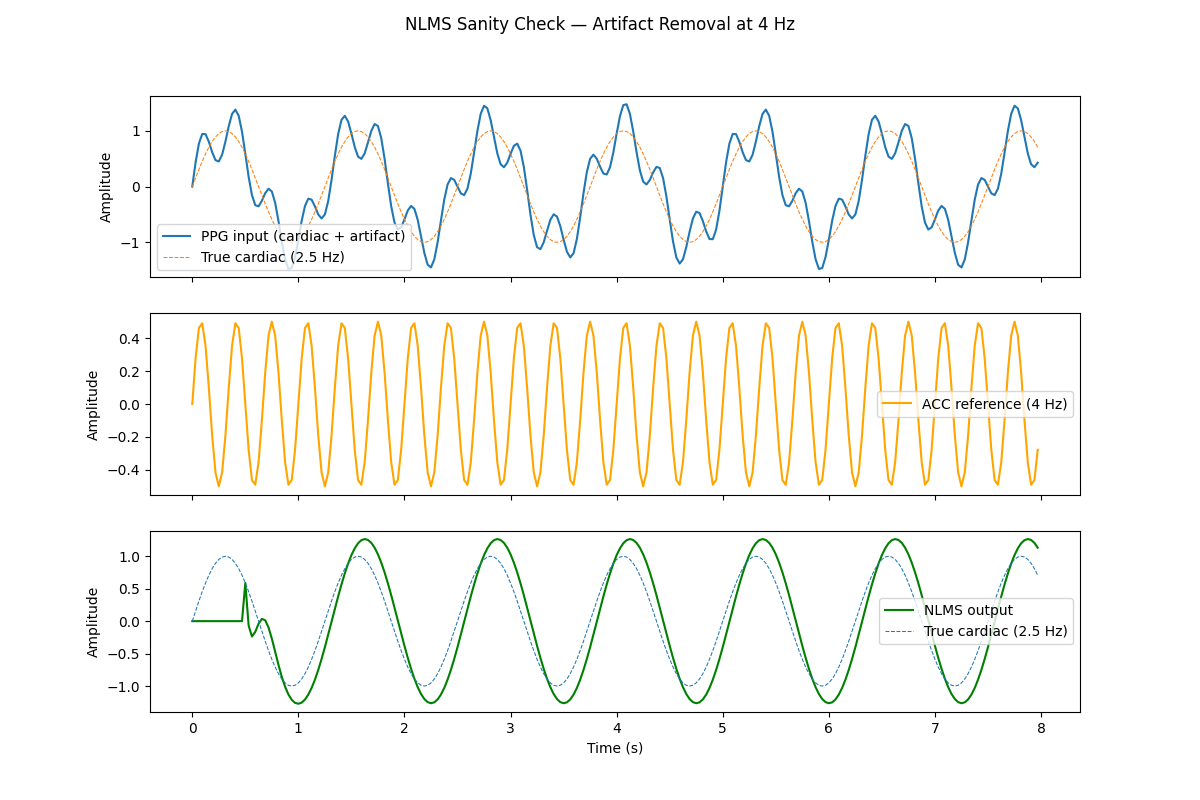

In [4]:
# NLMS check
#
# PPG = ___ Hz sine (cardiac) + ___ Hz sine at -6 dB (artifact)
# ACC = ___ Hz sine (motion reference)
# Expect: substantial removal of ___ Hz component from PPG after NLMS

FS_TEST = 32
T_TEST = 8.0
N_TEST = int(FS_TEST * T_TEST)
t_test = np.arange(N_TEST) / FS_TEST

# Construct signals
f_cardio = 0.8
f_artifact = 3.0
cardiac  = np.sin(2 * np.pi * f_cardio * t_test)
artifact = 0.5 * np.sin(2 * np.pi * f_artifact * t_test)  # -6 dB ~ amplitude 0.5

ppg_test = (cardiac + artifact).reshape(-1, 1)
acc_test = artifact.reshape(-1, 1)  # single channel reference

# Run NLMS
MU_TEST         = 0.5
FILTER_LEN_TEST = 16
ppg_clean_test  = nlms_filter(ppg_test, acc_test, mu=MU_TEST, filter_len=FILTER_LEN_TEST)

# Quantify suppression via FFT
def power_at_freq(signal, target_freq, fs):
    N = len(signal)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    spectrum = np.abs(np.fft.rfft(signal)) ** 2
    idx = np.argmin(np.abs(freqs - target_freq))
    return spectrum[idx]

p_before = power_at_freq(ppg_test[:, 0],       f_artifact, FS_TEST)
p_after  = power_at_freq(ppg_clean_test[:, 0], f_artifact, FS_TEST)
suppression_db = 10 * np.log10(p_after / p_before)
print(f"{f_artifact} Hz power before NLMS: {p_before:.4f}")
print(f"{f_artifact} Hz power after NLMS:  {p_after:.4f}")
print(f"Suppression:            {suppression_db:.1f} dB")

# Plot
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t_test, ppg_test[:, 0], label='PPG input (cardiac + artifact)')
ax[0].plot(t_test, cardiac, '--', label='True cardiac (2.5 Hz)', lw=0.75)
ax[0].set_ylabel('Amplitude')
ax[0].legend()
ax[1].plot(t_test, acc_test[:, 0], label='ACC reference (4 Hz)', color='orange')
ax[1].set_ylabel('Amplitude')
ax[1].legend()
ax[2].plot(t_test, ppg_clean_test[:, 0], label='NLMS output', color='green')
ax[2].plot(t_test, cardiac, '--', label='True cardiac (2.5 Hz)', lw=0.75)
ax[2].set_ylabel('Amplitude')
ax[2].set_xlabel('Time (s)')
ax[2].legend()
plt.suptitle('NLMS Sanity Check — Artifact Removal at 4 Hz')
plt.show()

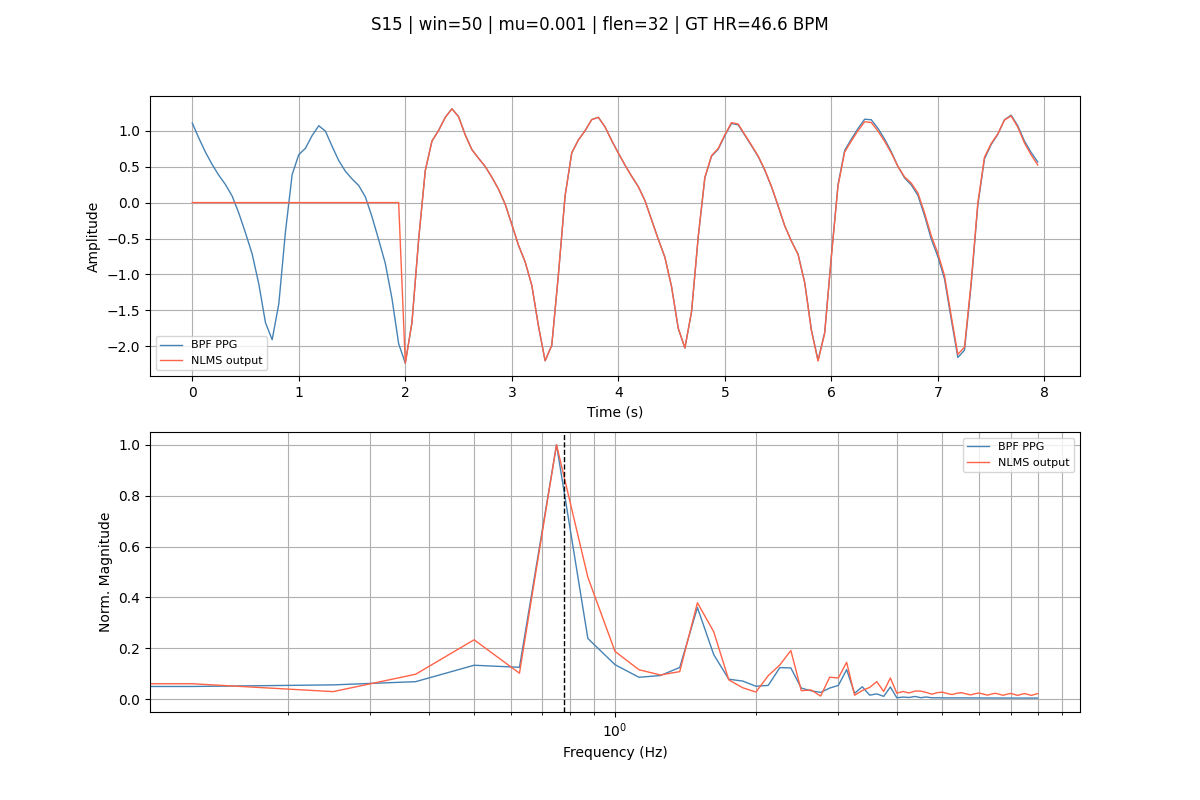

In [5]:
# Plot NLMS for one subject, one window

SUBJ_TEST    = 'S15'
WIN_TEST     = 50
MU_TEST      = 0.001
FILT_LEN_TEST = 32

ppg_win  = data_preproc[SUBJ_TEST]['ppg'][WIN_TEST]
acc_win  = data_preproc[SUBJ_TEST]['acc'][WIN_TEST]
hr_gt    = data_preproc[SUBJ_TEST]['label'][WIN_TEST]

ppg_clean = nlms_filter(ppg_win, acc_win, mu=MU_TEST, filter_len=FILT_LEN_TEST)
ppg_comb  = np.mean(ppg_clean, axis=1)

t_win = np.arange(N_WIN) / FS
f_hz  = rfftfreq(N_WIN, d=1/FS)
X_in  = np.abs(rfft(ppg_win[:, 0]))
X_out = np.abs(rfft(ppg_comb))
X_in  /= np.max(X_in)
X_out /= np.max(X_out)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(t_win, ppg_win[:, 0], lw=1.0, color='steelblue', label='BPF PPG')
axes[0].plot(t_win, ppg_comb,      lw=1.0, color='tomato',    label='NLMS output')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].semilogx(f_hz, X_in,  lw=1.0, color='steelblue', label='BPF PPG')
axes[1].semilogx(f_hz, X_out, lw=1.0, color='tomato',    label='NLMS output')
axes[1].axvline(hr_gt / 60, color='k', linestyle='--', lw=1.0)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Norm. Magnitude')
axes[1].legend(fontsize=8)
axes[1].grid(True, which='both')

plt.suptitle(f'{SUBJ_TEST} | win={WIN_TEST} | mu={MU_TEST} | flen={FILT_LEN_TEST} | GT HR={hr_gt:.1f} BPM')
plt.show()

## NLMS limitations

- Over a range of subjects, window indices (activities), filter lengths, and mu parameters, it seems that NLMS adaptive filtering provides no noise suppression benefits, and in some cases can degrade the actual PPG data
- This could be due to linearity breaking down (the motion artifacts in the DaLiA dataset are not sufficiently linearly correlated with the acc reference signal, despite NLMS being used in the literature for this purpose)

## Empirical Mode Decomposition (EMD)

EMD is inherently nonlinear and specific to the dataset, comparable to a wavelet decomp but with flexibility and nonlinearity baked in.

PPG — 4 IMFs | reconstruction error: 6.94e-18
ACC x — 4 IMFs | reconstruction error: 2.76e-18
ACC y — 5 IMFs | reconstruction error: 1.39e-17
ACC z — 4 IMFs | reconstruction error: 1.39e-17


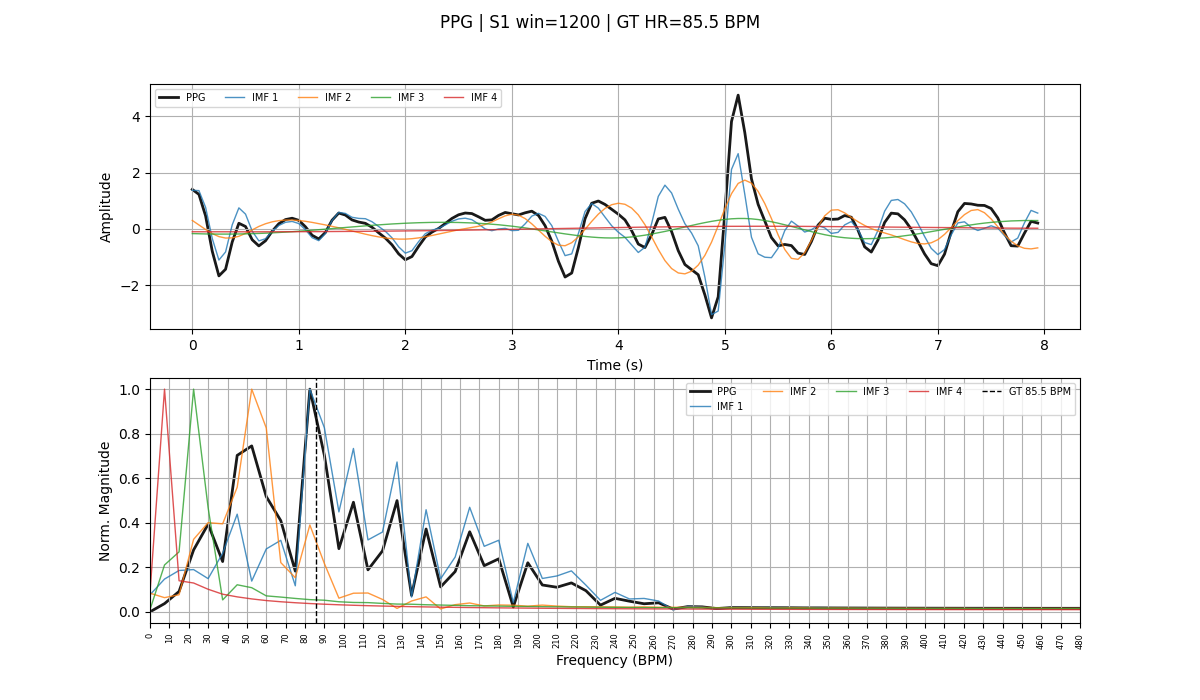

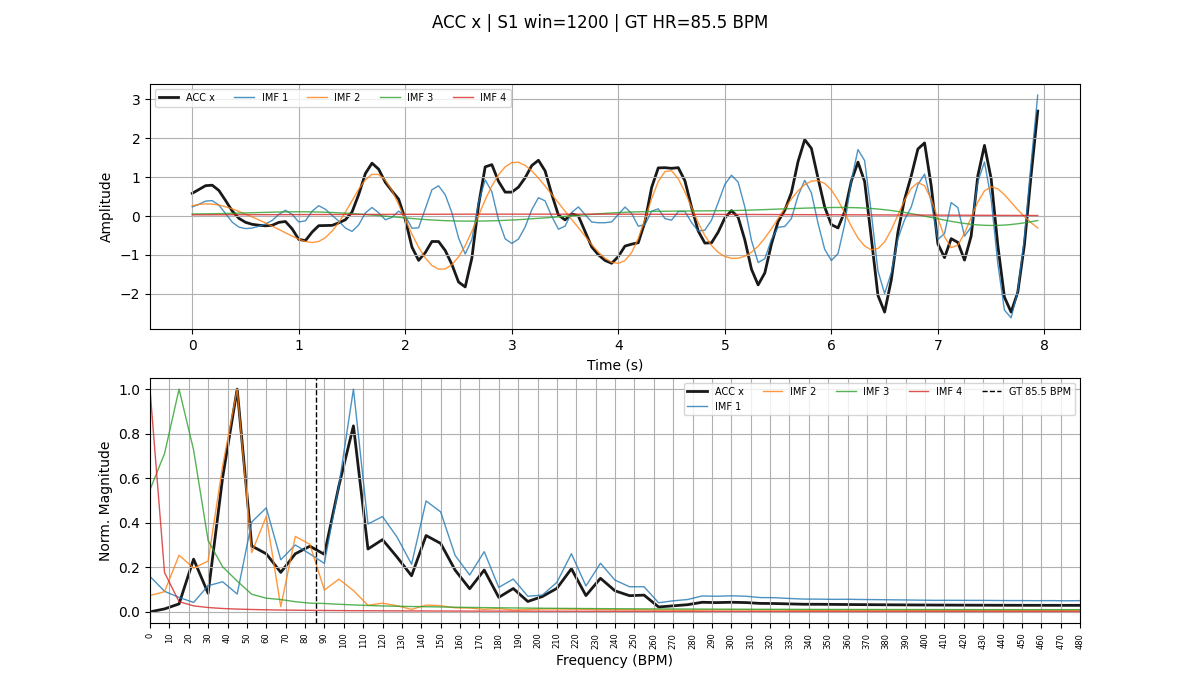

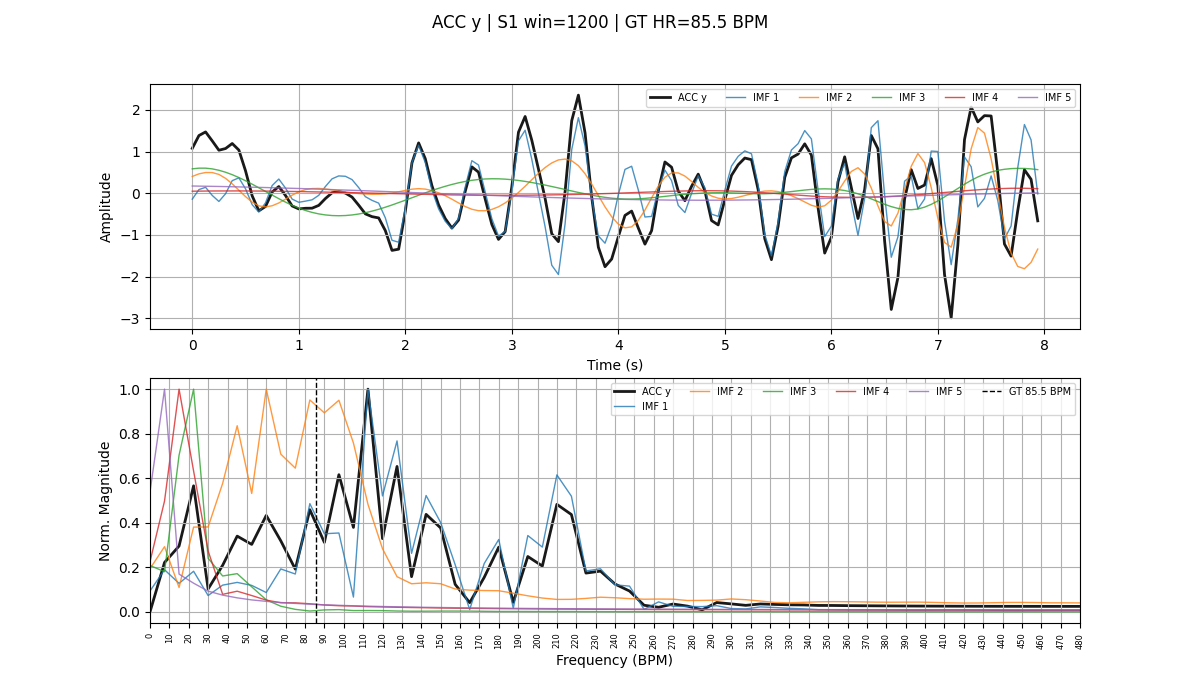

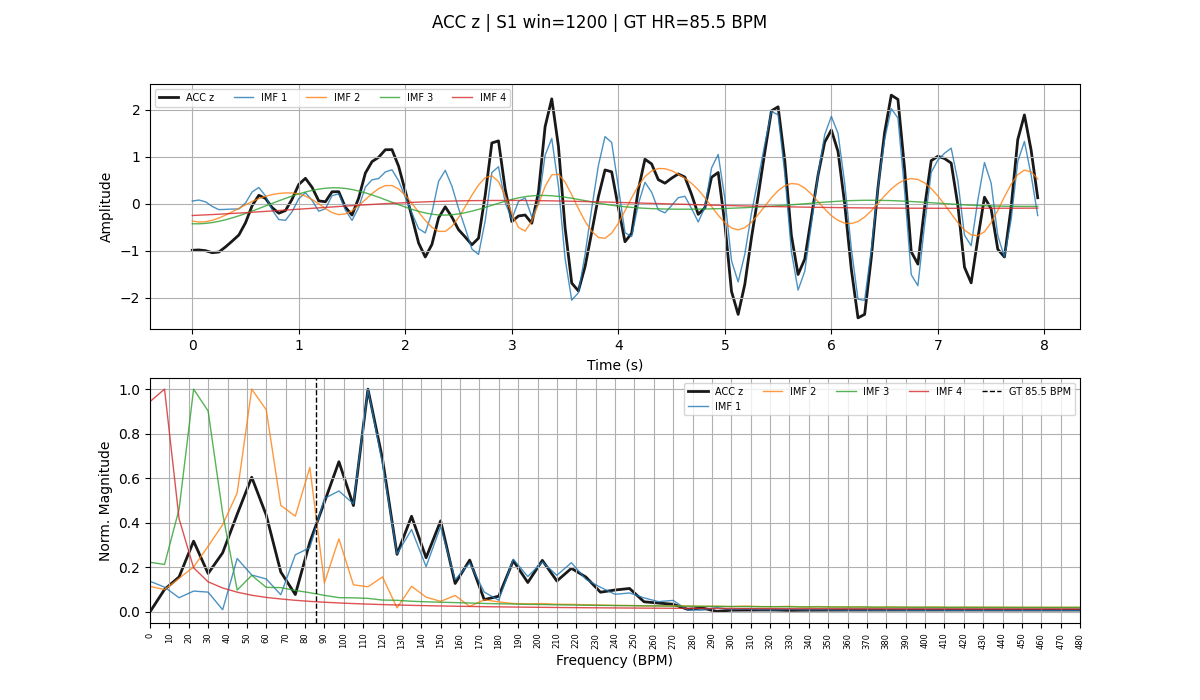

In [6]:
# EMD exploration — time and frequency domain

from PyEMD import EMD
plt.close('all')

emd = EMD()

SUBJ_TEST = 'S1'
WIN_TEST  = 1200

ppg_win = data_preproc[SUBJ_TEST]['ppg'][WIN_TEST, :, 0]
acc_win = data_preproc[SUBJ_TEST]['acc'][WIN_TEST]
hr_gt   = data_preproc[SUBJ_TEST]['label'][WIN_TEST]
t_win   = np.arange(N_WIN) / FS
f_hz    = rfftfreq(N_WIN, d=1/FS)
f_bpm   = f_hz * 60

# Decompose
signals = {
    'PPG':   ppg_win,
    'ACC x': acc_win[:, 0],
    'ACC y': acc_win[:, 1],
    'ACC z': acc_win[:, 2],
}

IMFs = {name: emd(sig) for name, sig in signals.items()}

for name, imfs in IMFs.items():
    err = np.max(np.abs(signals[name] - imfs.sum(axis=0)))
    print(f"{name} — {len(imfs)} IMFs | reconstruction error: {err:.2e}")

# Plot — 4 sets of 2x1 subplots
for name, sig in signals.items():
    imfs = IMFs[name]
    X_sig = np.abs(rfft(sig))
    X_sig /= np.max(X_sig)

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))

    # Time domain
    axes[0].plot(t_win, sig, lw=2, color='k', alpha=0.9, label=name, zorder=1)
    for i, imf in enumerate(imfs):
        axes[0].plot(t_win, imf, lw=1, label=f'IMF {i+1}', alpha=0.8, zorder=2)
    axes[0].set_ylabel('Amplitude')
    axes[0].set_xlabel('Time (s)')
    axes[0].legend(fontsize=7, ncol=len(imfs) + 1)
    axes[0].grid(True)

    # Frequency domain — x axis in BPM, linear scale
    axes[1].plot(f_bpm, X_sig, lw=2, color='k', alpha=0.9, label=name, zorder=1)
    for i, imf in enumerate(imfs):
        X = np.abs(rfft(imf))
        X /= np.max(X)
        axes[1].plot(f_bpm, X, lw=1, label=f'IMF {i+1}', alpha=0.8, zorder=2)
    axes[1].axvline(hr_gt, color='k', linestyle='--', lw=1.0,
                    label=f'GT {hr_gt:.1f} BPM')
    axes[1].set_xlim(f_bpm[1], f_bpm[-1])
    axes[1].set_xlabel('Frequency (BPM)')
    axes[1].set_ylabel('Norm. Magnitude')
    axes[1].legend(fontsize=7, ncol=len(imfs) + 1)

    # Grid marks and labels at every BPM tick
    bpm_ticks = np.arange(0, f_bpm[-1] + 1, 10)
    axes[1].set_xticks(bpm_ticks)
    axes[1].set_xticklabels([f'{int(b)}' for b in bpm_ticks], fontsize=6, rotation=90)
    axes[1].grid(True, which='both')

    plt.suptitle(f'{name} | {SUBJ_TEST} win={WIN_TEST} | GT HR={hr_gt:.1f} BPM')
    plt.show()

## EMD notes

## EMD limitations for this application
- IMF1 contains the majority of signal energy in nearly all windows
- Cardiac content distributed across IMF1 and IMF2, making automated IMF selection unreliable
- BPF already constrains the signal to 0.4–4 Hz before decomp, leaving EMD little additional structure to separate

## Replica Correlation

- Simulate clean PPG at different HRs and correlate

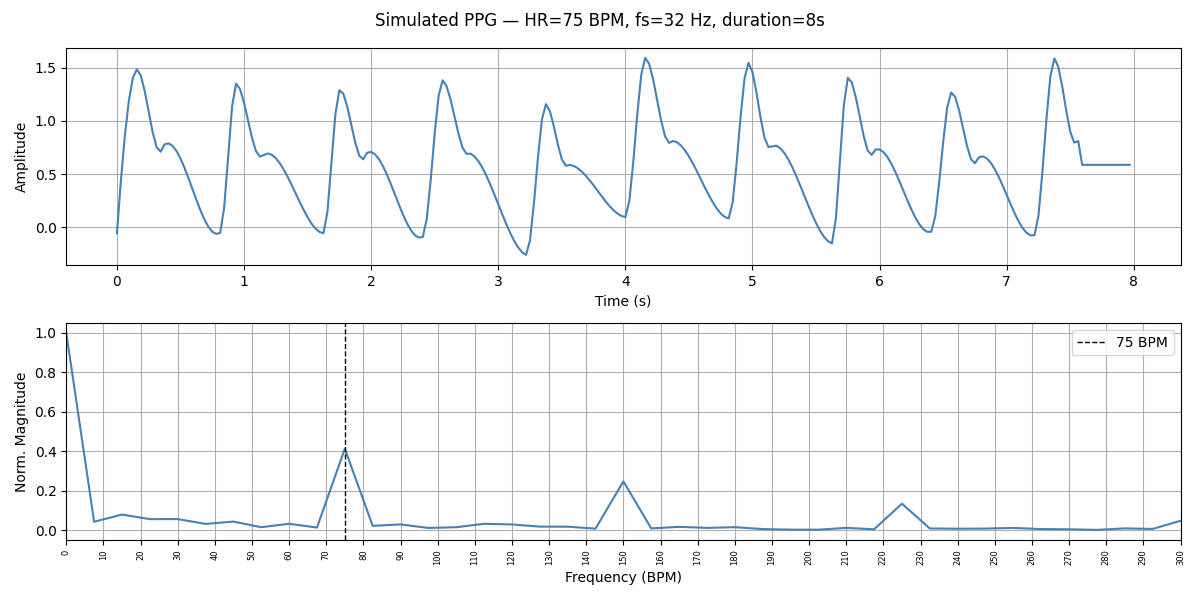

In [7]:
# Simulate PPG signal

import neurokit2 as nk

# Simulate clean PPG signal
FS_SIM   = 32
DUR_SIM  = 8      # seconds — one window
HR_SIM   = 75     # BPM

ppg_sim = nk.ppg_simulate(
    duration          = DUR_SIM,
    sampling_rate     = FS_SIM,
    heart_rate        = HR_SIM,
    frequency_modulation = 0,
    ibi_randomness    = 0,
    drift             = 0,
    motion_amplitude  = 0,
    powerline_amplitude = 0,
    burst_amplitude = 0,
    burst_number = 0,
    random_state      = 42,
)

t_sim   = np.arange(len(ppg_sim)) / FS_SIM
f_hz    = rfftfreq(len(ppg_sim), d=1/FS_SIM)
f_bpm   = f_hz * 60
X_sim   = np.abs(rfft(ppg_sim))
X_sim  /= np.max(X_sim)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t_sim, ppg_sim, lw=1.5, color='steelblue')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

axes[1].plot(f_bpm, X_sim, lw=1.5, color='steelblue')
axes[1].axvline(HR_SIM, color='k', linestyle='--', lw=1.0, label=f'{HR_SIM} BPM')
axes[1].set_xlabel('Frequency (BPM)')
axes[1].set_ylabel('Norm. Magnitude')
axes[1].set_xlim(0, 300)
bpm_ticks = np.arange(0, 301, 10)
axes[1].set_xticks(bpm_ticks)
axes[1].set_xticklabels([f'{int(b)}' for b in bpm_ticks], fontsize=6, rotation=90)
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f'Simulated PPG — HR={HR_SIM} BPM, fs={FS_SIM} Hz, duration={DUR_SIM}s')
plt.tight_layout()
plt.show()

### Neurokit implementation notes

- Neurokit simulated PPG uses interpolation between time series landmarks, introducing inherent inconsistency (at least in amplitude) even with all artifact dials zeroed
- Build homemade harmonic series instead

In [8]:
def ppg_sim(hr_bpm, duration, fs):
    """
    Simulate a synthetic PPG signal using empirically-derived harmonic amplitudes

    Constructs the signal as a sum of sinusoids at integer multiples of the
    fundamental cardiac frequency f0 = hr_bpm / 60, with harmonic amplitudes
    based on measured fingertip PPG spectral ratios:

        Perdereau et al. (2025), "Clinical validation of comprehensive time- and
        frequency-domain photoplethysmography features from a single-sensor system
        for non-invasive assessment of vascular load and systolic blood pressure,"
        Frontiers in Physiology. DOI: 10.3389/fphys.2025.1695391

        Reported harmonic amplitude ratios (normotensive group, fingertip PPG):
            H1 = 1.00 (fundamental, normalized)
            H2/H1 ≈ 0.71
            H3/H1 ≈ 0.15

    Note: ratios derived from fingertip PPG at 500 Hz in a clinical population.

    Harmonics exceeding the Nyquist frequency (fs / 2) are automatically excluded.

    Inputs:
        hr_bpm:   float  heart rate in BPM
        duration: float  signal duration in seconds
        fs:       int    sample rate in Hz

    Returns:
        ppg:      (N,)  synthetic PPG signal, zero-mean unit-std normalized
    """

    assert hr_bpm > 0,   "hr_bpm must be positive"
    assert duration > 0, "duration must be positive"
    assert fs > 0,       "fs must be positive"

    f0        = hr_bpm / 60.0
    f_nyquist = fs / 2.0
    N         = int(duration * fs)
    t         = np.arange(N) / fs

    harm_amps = {1: 1.00, 2: 0.71, 3: 0.15}

    ppg = np.zeros(N)
    included = []
    for k, amp in harm_amps.items():
        if k * f0 >= f_nyquist:
            break
        ppg += amp * np.sin(2 * np.pi * k * f0 * t)
        included.append(k)

    print(f"HR={hr_bpm} BPM | f0={f0:.3f} Hz | Nyquist={f_nyquist} Hz | "
          f"harmonics included: {included}")

    # Zero-mean unit-std normalize
    ppg = (ppg - np.mean(ppg)) / np.std(ppg)

    return ppg

HR=60 BPM | f0=1.000 Hz | Nyquist=8.0 Hz | harmonics included: [1, 2, 3]


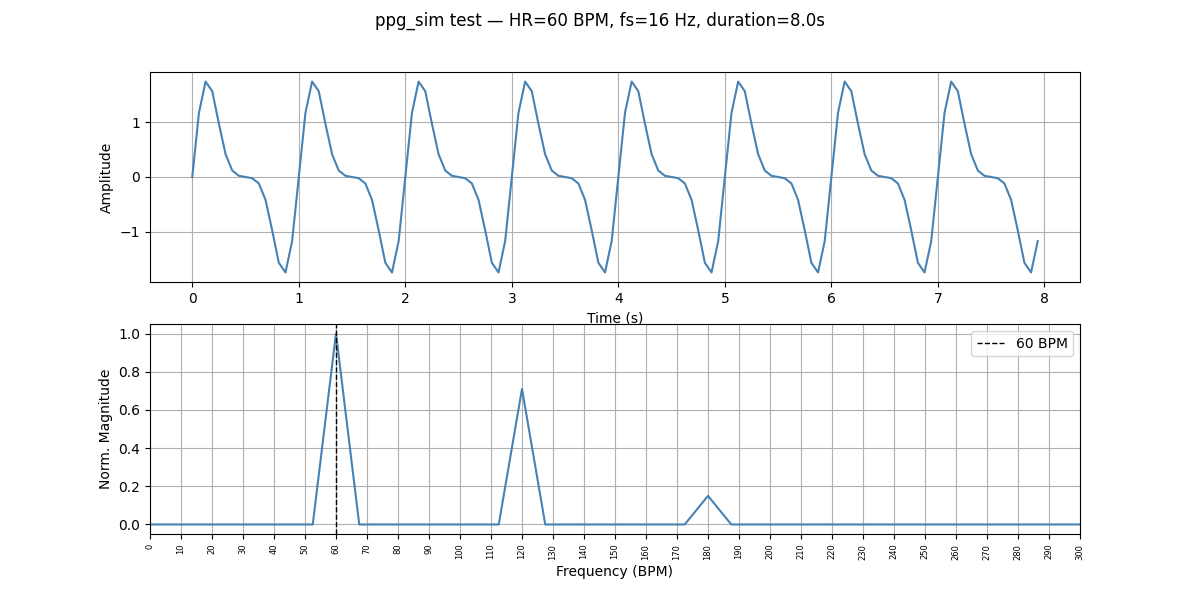

In [9]:
# ppg_sim test

HR_TEST  = 60
DUR_TEST = 8.0

ppg_test = ppg_sim(HR_TEST, DUR_TEST, FS)
t_test   = np.arange(len(ppg_test)) / FS
f_hz     = rfftfreq(len(ppg_test), d=1/FS)
f_bpm    = f_hz * 60
X_test   = np.abs(rfft(ppg_test))
X_test  /= np.max(X_test)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t_test, ppg_test, lw=1.5, color='steelblue')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

axes[1].plot(f_bpm, X_test, lw=1.5, color='steelblue')
axes[1].axvline(HR_TEST, color='k', linestyle='--', lw=1.0, label=f'{HR_TEST} BPM')
axes[1].set_xlabel('Frequency (BPM)')
axes[1].set_ylabel('Norm. Magnitude')
axes[1].set_xlim(0, 300)
bpm_ticks = np.arange(0, 301, 10)
axes[1].set_xticks(bpm_ticks)
axes[1].set_xticklabels([f'{int(b)}' for b in bpm_ticks], fontsize=6, rotation=90)
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f'ppg_sim test — HR={HR_TEST} BPM, fs={FS} Hz, duration={DUR_TEST}s')
plt.show()

In [10]:
def ecg_sim(hr_bpm, duration, fs, snr_db, randomness=0.0, random_state=42):
    """
    Simulate a simplified ECG-like signal as a series of delayed impulses
    representing R-peaks, with additive Gaussian noise and timing jitter.

    Args:
        hr_bpm:       float  heart rate in BPM
        duration:     float  signal duration in seconds
        fs:           int    sample rate in Hz
        snr_db:       float  signal-to-noise ratio in dB
        randomness:   float  timing jitter factor in [0, 1].
                             0 = perfectly regular spacing,
                             1 = up to +/- IBI/2 variation per beat
        random_state: int    seed for reproducibility

    Returns:
        ecg:          (N,)   simulated ECG signal
        r_peaks:      list   sample indices of R-peak locations
    """

    N        = int(duration * fs)
    ibi_samp = fs * 60.0 / hr_bpm   # ideal inter-beat interval in samples
    max_jitter = randomness * ibi_samp / 2.0
    
    assert hr_bpm > 0,          "hr_bpm must be positive"
    assert duration > 0,        "duration must be positive"
    assert fs > 0,              "fs must be positive"
    assert 0.0 <= randomness <= 1.0, "randomness must be in [0, 1]"
    assert N > 0, f"duration too short for fs={fs}: results in 0 samples"
    assert ibi_samp <= N, (f"IBI ({ibi_samp:.1f} samples) exceeds signal length "
                          f"({N} samples) — increase duration or reduce hr_bpm")

    rng = np.random.default_rng(random_state)



    # Place R-peaks
    ecg     = np.zeros(N)
    r_peaks = []
    t       = 0  # start after one IBI

    while t < N:
        idx = int(round(t))
        if 0 <= idx < N:
            ecg[idx] = 1.0
            r_peaks.append(idx)
        jitter = rng.uniform(-max_jitter, max_jitter)
        t += ibi_samp + jitter

    # Add Gaussian noise at specified SNR
    signal_power = np.mean(ecg ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise        = rng.normal(0, np.sqrt(noise_power), N)
    ecg         += noise
    ecg         /= np.max(ecg)

    print(f"HR={hr_bpm} BPM | duration={duration}s | fs={fs} Hz | "
          f"SNR={snr_db} dB | randomness={randomness} | R-peaks: {len(r_peaks)}")

    return ecg, r_peaks

HR=80 BPM | duration=8.0s | fs=16 Hz | SNR=6 dB | randomness=0.1 | R-peaks: 11
HR=40 BPM | duration=8.0s | fs=16 Hz | SNR=100 dB | randomness=0.0 | R-peaks: 6
BPM=  40 | peak NCC=0.3390
HR=45 BPM | duration=8.0s | fs=16 Hz | SNR=100 dB | randomness=0.0 | R-peaks: 6
BPM=  45 | peak NCC=0.2563
HR=50 BPM | duration=8.0s | fs=16 Hz | SNR=100 dB | randomness=0.0 | R-peaks: 7
BPM=  50 | peak NCC=0.1985
HR=55 BPM | duration=8.0s | fs=16 Hz | SNR=100 dB | randomness=0.0 | R-peaks: 8
BPM=  55 | peak NCC=0.1783
HR=60 BPM | duration=8.0s | fs=16 Hz | SNR=100 dB | randomness=0.0 | R-peaks: 8
BPM=  60 | peak NCC=0.2161
HR=65 BPM | duration=8.0s | fs=16 Hz | SNR=100 dB | randomness=0.0 | R-peaks: 9
BPM=  65 | peak NCC=0.2211
HR=70 BPM | duration=8.0s | fs=16 Hz | SNR=100 dB | randomness=0.0 | R-peaks: 10
BPM=  70 | peak NCC=0.2143
HR=75 BPM | duration=8.0s | fs=16 Hz | SNR=100 dB | randomness=0.0 | R-peaks: 10
BPM=  75 | peak NCC=0.3075
HR=80 BPM | duration=8.0s | fs=16 Hz | SNR=100 dB | randomness=

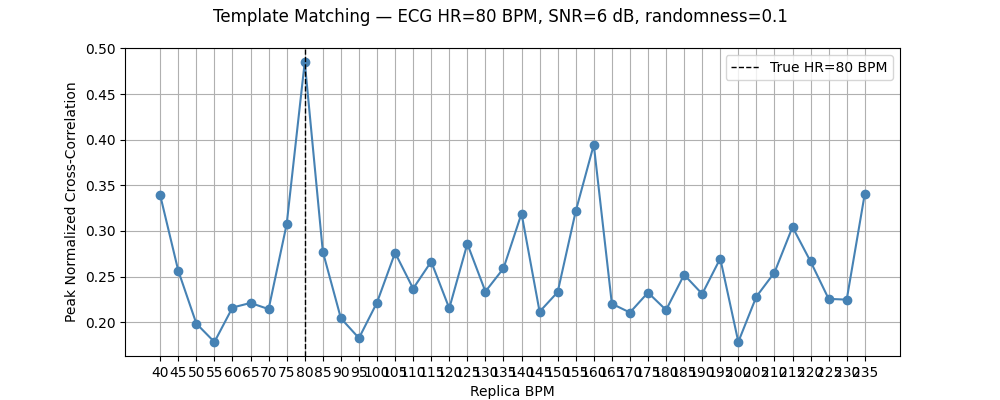

In [17]:
from scipy.signal import correlate

# Test signal
ECG_HR   = 80
ECG_DUR  = 8.0
ECG_SNR  = 6
ECG_RAND = 0.1

ecg_test, r_peaks_test = ecg_sim(ECG_HR, ECG_DUR, FS, ECG_SNR,
                                  randomness=ECG_RAND, random_state=42)

# Replicas — same duration as test signal, no noise, no jitter
replica_bpms = np.arange(40, 240, 5)

scores = {}
for bpm in replica_bpms:
    replica, _ = ecg_sim(bpm, ECG_DUR, FS, snr_db=100,
                          randomness=0.0, random_state=0)

    cc   = correlate(ecg_test, replica, mode='full')
    norm = np.linalg.norm(ecg_test) * np.linalg.norm(replica)
    ncc  = cc / norm
    scores[bpm] = np.max(np.abs(ncc))
    print(f"BPM={bpm:>4} | peak NCC={scores[bpm]:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(scores.keys()), list(scores.values()), 'o-', lw=1.5, color='steelblue')
ax.axvline(ECG_HR, color='k', linestyle='--', lw=1.0, label=f'True HR={ECG_HR} BPM')
ax.set_xlabel('Replica BPM')
ax.set_ylabel('Peak Normalized Cross-Correlation')
ax.set_xticks(replica_bpms)
ax.legend()
ax.grid(True)
plt.suptitle(f'Template Matching — ECG HR={ECG_HR} BPM, SNR={ECG_SNR} dB, '
             f'randomness={ECG_RAND}')
plt.show()

HR=60 BPM | f0=1.000 Hz | Nyquist=8.0 Hz | harmonics included: [1, 2, 3]
BPM=  60 | peak NCC=0.2994
HR=62 BPM | f0=1.033 Hz | Nyquist=8.0 Hz | harmonics included: [1, 2, 3]
BPM=  62 | peak NCC=0.2665
HR=64 BPM | f0=1.067 Hz | Nyquist=8.0 Hz | harmonics included: [1, 2, 3]
BPM=  64 | peak NCC=0.2878
HR=66 BPM | f0=1.100 Hz | Nyquist=8.0 Hz | harmonics included: [1, 2, 3]
BPM=  66 | peak NCC=0.3196
HR=68 BPM | f0=1.133 Hz | Nyquist=8.0 Hz | harmonics included: [1, 2, 3]
BPM=  68 | peak NCC=0.2924
HR=70 BPM | f0=1.167 Hz | Nyquist=8.0 Hz | harmonics included: [1, 2, 3]
BPM=  70 | peak NCC=0.3025
HR=72 BPM | f0=1.200 Hz | Nyquist=8.0 Hz | harmonics included: [1, 2, 3]
BPM=  72 | peak NCC=0.3834
HR=74 BPM | f0=1.233 Hz | Nyquist=8.0 Hz | harmonics included: [1, 2, 3]
BPM=  74 | peak NCC=0.3931
HR=76 BPM | f0=1.267 Hz | Nyquist=8.0 Hz | harmonics included: [1, 2, 3]
BPM=  76 | peak NCC=0.3684
HR=78 BPM | f0=1.300 Hz | Nyquist=8.0 Hz | harmonics included: [1, 2, 3]
BPM=  78 | peak NCC=0.3056


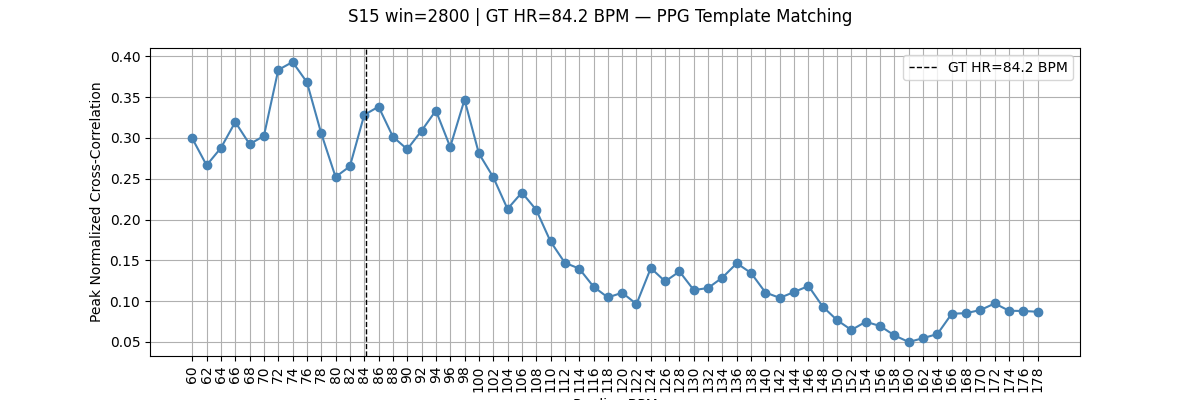

In [43]:
from scipy.signal import correlate
plt.close('all')

# Pluck a PPG window
SUBJ_TEST = 'S15'
WIN_TEST  = 2800

ppg_win = data_preproc[SUBJ_TEST]['ppg'][WIN_TEST, :, 0]  # (N_WIN,)
hr_gt   = data_preproc[SUBJ_TEST]['label'][WIN_TEST]

# PPG replicas — same duration as window, no noise
replica_bpms = np.arange(60, 180, 2)

scores = {}
for bpm in replica_bpms:
    replica = ppg_sim(bpm, T_WIN, FS)

    cc   = correlate(ppg_win, replica, mode='full')
    norm = np.linalg.norm(ppg_win) * np.linalg.norm(replica)
    ncc  = cc / norm
    scores[bpm] = np.max(np.abs(ncc))
    print(f"BPM={bpm:>4} | peak NCC={scores[bpm]:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(list(scores.keys()), list(scores.values()), 'o-', lw=1.5, color='steelblue')
ax.axvline(hr_gt, color='k', linestyle='--', lw=1.0, label=f'GT HR={hr_gt:.1f} BPM')
ax.set_xlabel('Replica BPM')
ax.set_ylabel('Peak Normalized Cross-Correlation')
ax.set_xticks(replica_bpms)
ax.set_xticklabels([str(b) for b in replica_bpms], rotation=90)
ax.legend()
ax.grid(True)
plt.suptitle(f'{SUBJ_TEST} win={WIN_TEST} | GT HR={hr_gt:.1f} BPM — PPG Template Matching')
plt.show()

## Replica Correlation Notes
- Norm cross corr between simulated ppg (dominated by harmonics 1 and 2) unreliable as HR increases and is often confused with harmonics of the ground truth HR frequency
- Xcorr with replicas even at fine HR resolution unlikely to help zero in on ground truth HR on average

## Data cleaning notes

- Performance of linear operations (NLMS adaptive filtering and Replica Corrlation) to increase SNR inadequate
- Nonlinear operation EMD could not separate cardiac dominated mode likely due to agressive band pass filtering in the preprocessing step
    - cursory test showed EMD on raw data not likely to help more than working with preprocessed PPG and ACC
 
### Way Forward
- Operate on preprocessed PPG and ACC channels without further data cleaning before prediction algorithm